# Notebook 02 – Database Matching

**Objetivo:** Hacer matching automático entre los picos limpios del GC-MS y la BD de 40k metabolitos.

## Importe de librerías

In [1]:
import pandas as pd
import numpy as np
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

DATA_RAW  = Path('../data/raw')
DATA_PROC = Path('../data/processed')
FIGS      = Path('../results/figures')

print('✓ Librerías importadas')

✓ Librerías importadas


## 1. Carga de datos Notebook01 y base de datos de 39K metabolitos relacionados con enfermedades mentales

In [2]:
peaks_clean = pd.read_csv(DATA_PROC / 'peaks_clean.csv')

biomarkers_db = pd.read_excel(
    DATA_RAW / 'MH_Biomarkers_Salud_Mental_CURADO.xlsx',
    sheet_name='MH_Biomarkers_CURADO'
)

print('=' * 70)
print('DATOS CARGADOS')
print('=' * 70)
print(f'Picos limpios:       {len(peaks_clean)}')
print(f'Metabolitos en BD:   {len(biomarkers_db)}')
print(f'\nColumnas BD: {biomarkers_db.columns.tolist()}')

# Cuántos tienen Flag_contaminante en la BD
if 'Flag_contaminante' in biomarkers_db.columns:
    print(f'\nFlag_contaminante en BD:')
    print(biomarkers_db['Flag_contaminante'].value_counts())

DATOS CARGADOS
Picos limpios:       372
Metabolitos en BD:   38952

Columnas BD: ['ID', 'Nombre canonico', 'InChIKey', 'CID', 'Condiciones', '#C', '#F', '#L', 'Fuentes', 'Matriz', 'Metodo', 'Evidencia', 'Volatilidad', 'Vinculo Microbio.', 'Tipo Vinculo', 'Flag_contaminante', 'Origen_probable', 'Origen_alternativos', 'Confianza_origen', 'Motivo_origen']

Flag_contaminante en BD:
Flag_contaminante
No                      37881
Posible_contaminante     1071
Name: count, dtype: int64


In [3]:
# Usamos la BD completa — si un pico coincide con un Posible_contaminante
# quedará marcado automáticamente en la columna Flag_contaminante al enriquecer
db_valid = biomarkers_db.copy()

# ─────────────────────────────────────────────────────────────────────────────
# Por qué dos listas:
#   db_names       → nombres ORIGINALES de la BD  (ej: "Acetone", "n-hexane")
#   db_names_lower → los mismos en minúsculas      (ej: "acetone", "n-hexane")
#
# La búsqueda se hace contra db_names_lower (case-insensitive),
# pero el resultado devuelto es db_names[idx] para conservar
# el nombre oficial de la BD con sus mayúsculas originales.
# ─────────────────────────────────────────────────────────────────────────────
db_names       = db_valid['Nombre canonico'].dropna().unique().tolist()
db_names_lower = [n.lower() for n in db_names]

# Para el lookup: si hay duplicados en 'Nombre canonico', nos quedamos con la primera ocurrencia
db_lookup = (
    db_valid.drop_duplicates(subset='Nombre canonico')
    .set_index('Nombre canonico')
    .to_dict('index')
)

print(f'BD completa para matching: {len(db_names)} metabolitos')
n_dup = db_valid['Nombre canonico'].dropna().duplicated().sum()
if n_dup > 0:
    print(f'  ({n_dup} filas duplicadas en Nombre canonico → se usa la primera ocurrencia)')
if 'Flag_contaminante' in biomarkers_db.columns:
    print(f'  (incluye {(biomarkers_db["Flag_contaminante"] == "Posible_contaminante").sum()} marcados como Posible_contaminante → se marcarán en el output)')

BD completa para matching: 38950 metabolitos
  (1 filas duplicadas en Nombre canonico → se usa la primera ocurrencia)
  (incluye 1071 marcados como Posible_contaminante → se marcarán en el output)


## 3. Matching

In [4]:
def find_best_match(peak_name, db_names_lower, db_names):
    """
    Solo match exacto (case-insensitive).
    Devuelve: (nombre_bd, score, método)
    """
    if pd.isna(peak_name):
        return None, 0.0, 'no_match'

    peak_lower = peak_name.lower().strip()

    if peak_lower in db_names_lower:
        idx = db_names_lower.index(peak_lower)
        return db_names[idx], 1.0, 'exact'

    return None, 0.0, 'no_match'

print('Función de matching definida (solo match exacto).')
print('Iniciando matching...')

Función de matching definida (solo match exacto).
Iniciando matching...


In [5]:
def find_derivative(peak_name, db_names_lower, db_names):
    """
    Busca si el pico es la base de algún derivado en la BD, o viceversa.
    Un derivado se detecta cuando el nombre del pico aparece al inicio
    del nombre de la BD seguido de ',' o ' ' (ej: "Acetone" → "Acetone, 2-methyl-").
    NO se considera el mismo compuesto — se marca como 'derivative' para revisión.
    """
    if pd.isna(peak_name):
        return None, 'no_match'
    peak_lower = peak_name.lower().strip()
    for orig, low in zip(db_names, db_names_lower):
        if low.startswith(peak_lower + ',') or low.startswith(peak_lower + ' '):
            return orig, 'derivative'
        if peak_lower.startswith(low + ',') or peak_lower.startswith(low + ' '):
            return orig, 'derivative'
    return None, 'no_match'

# ── Paso 1: match exacto ─────────────────────────────────────────────────────
results = []
for compound in peaks_clean['Compound Name'].tolist():
    matched_name, score, method = find_best_match(compound, db_names_lower, db_names)
    results.append({
        'compound_name':     compound,
        'matched_biomarker': matched_name,
        'match_score':       score,
        'match_method':      method,
    })

matches_df = pd.DataFrame(results)

# ── Paso 2: buscar derivados solo entre los sin match ────────────────────────
no_match_mask = matches_df['match_method'] == 'no_match'
for idx, row in matches_df[no_match_mask].iterrows():
    deriv_name, deriv_method = find_derivative(row['compound_name'], db_names_lower, db_names)
    if deriv_name:
        matches_df.at[idx, 'matched_biomarker'] = deriv_name
        matches_df.at[idx, 'match_method']      = deriv_method

# ── Resumen ───────────────────────────────────────────────────────────────────
n_exact      = (matches_df['match_method'] == 'exact').sum()
n_derivative = (matches_df['match_method'] == 'derivative').sum()
n_unmatched  = (matches_df['match_method'] == 'no_match').sum()

print('=' * 70)
print('RESULTADOS DEL MATCHING')
print('=' * 70)
print(f'  Total picos:          {len(matches_df)}')
print(f'  Match exacto:         {n_exact}')
print(f'  Match derivado:       {n_derivative}')
print(f'  Sin match:            {n_unmatched}')
print(f'\n  → Pasan al análisis:  {n_exact + n_derivative} picos (exactos + derivados)')

RESULTADOS DEL MATCHING
  Total picos:          372
  Match exacto:         127
  Match derivado:       76
  Sin match:            169

  → Pasan al análisis:  203 picos (exactos + derivados)


## 4. Resultados de los metabolitos que han hecho match

In [7]:
# Añadir Hit 1: Match Factor por posición (mismo orden que peaks_clean)
matches_df['Hit 1: Match Factor'] = peaks_clean['Hit 1: Match Factor'].values

# De los que hicieron match, filtrar >= 700
analysis_df = matches_df[
    (matches_df['match_method'] != 'no_match') &
    (matches_df['Hit 1: Match Factor'] >= 700)
].copy()
analysis_df = analysis_df.sort_values('Hit 1: Match Factor', ascending=False).reset_index(drop=True)
analysis_df.index += 1

print(f'Picos con match:               {(matches_df["match_method"] != "no_match").sum()}')
print(f'Con Hit 1: Match Factor ≥ 700: {len(analysis_df)}')
analysis_df

Picos con match:               203
Con Hit 1: Match Factor ≥ 700: 169


,compound_name,matched_biomarker,match_score,match_method,Hit 1: Match Factor
1,Indole,indole,1.0,exact,972
2,Caryophyllene,caryophyllene,1.0,exact,971
3,"Phenol, 4-ethyl-","Phenol, 4-ethyl-",1.0,exact,967
4,Benzeneacetaldehyde,Benzeneacetaldehyde,1.0,exact,963
5,"Disulfide, dimethyl","Disulfide, dimethyl",1.0,exact,962
...,...,...,...,...,...
165,"5-Hepten-2-one, 6-methyl-","5-Hepten-2-one, 6-methyl-",1.0,exact,712
166,2-Hexadecanone,2-Hexadecanone,1.0,exact,709
167,"4-Methylcatechol, 2TMS derivative",4-methylcatechol,0.0,derivative,704
168,1-Pentadecene,1-pentadecene,1.0,exact,704


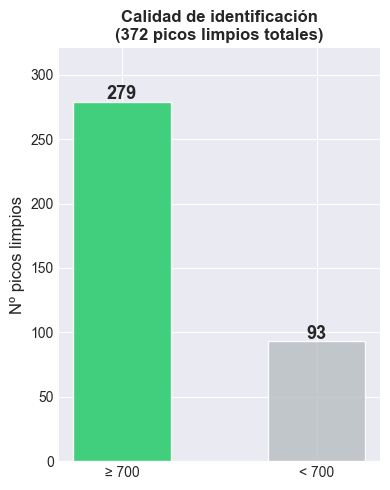

✓ Figura guardada: results/figures/02_all_peaks_match_factor.png


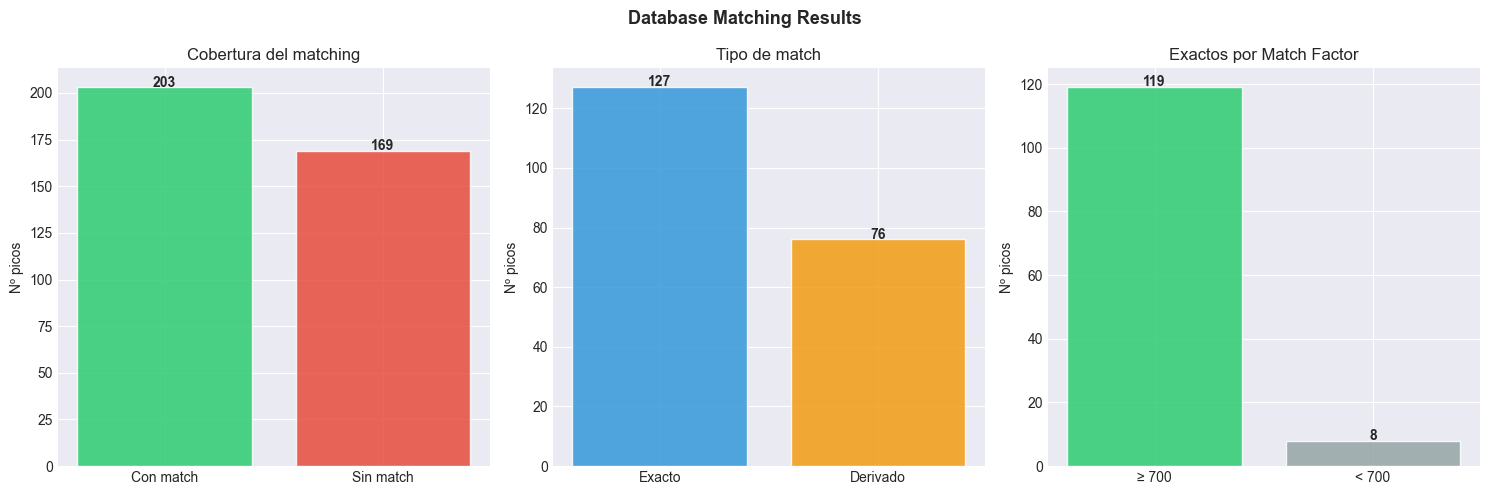

✓ Figura guardada: results/figures/02_matching_results.png


In [17]:
all_peaks = peaks_clean[['Compound Name', 'Hit 1: Match Factor']].copy()
threshold = 700
n_above = (all_peaks['Hit 1: Match Factor'] >= threshold).sum()
n_below  = len(all_peaks) - n_above

fig, ax = plt.subplots(figsize=(4, 5))
bars = ax.bar(['≥ 700', '< 700'], [n_above, n_below],
              color=['#2ecc71', '#bdc3c7'], alpha=0.9, edgecolor='white', width=0.5)
ax.set_ylabel('Nº picos limpios', fontsize=12)
ax.set_title(f'Calidad de identificación\n({len(all_peaks)} picos limpios totales)', fontsize=12, fontweight='bold')
for bar, val in zip(bars, [n_above, n_below]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(n_above, n_below) * 1.15)
plt.tight_layout()
plt.savefig(FIGS / '02_all_peaks_match_factor.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Figura guardada: results/figures/02_all_peaks_match_factor.png')

n_matched    = (matches_df['match_method'] != 'no_match').sum()
n_unmatched  = (matches_df['match_method'] == 'no_match').sum()
n_exact      = (matches_df['match_method'] == 'exact').sum()
n_derivative = (matches_df['match_method'] == 'derivative').sum()
n_exact_700  = len(analysis_df[analysis_df['match_method'] == 'exact'])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Database Matching Results', fontsize=13, fontweight='bold')

# Plot 1: Match vs No match
ax = axes[0]
ax.bar(['Con match', 'Sin match'], [n_matched, n_unmatched],
       color=['#2ecc71', '#e74c3c'], alpha=0.85, edgecolor='white')
ax.set_ylabel('Nº picos')
ax.set_title('Cobertura del matching')
for bar, val in zip(ax.patches, [n_matched, n_unmatched]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', fontweight='bold')

# Plot 2: Exacto vs Derivado
ax = axes[1]
ax.bar(['Exacto', 'Derivado'], [n_exact, n_derivative],
       color=['#3498db', '#f39c12'], alpha=0.85, edgecolor='white')
ax.set_ylabel('Nº picos')
ax.set_title('Tipo de match')
for bar, val in zip(ax.patches, [n_exact, n_derivative]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', fontweight='bold')

# Plot 3: Exactos con Match Factor >= 700 vs < 700
n_exact_below = n_exact - n_exact_700
ax = axes[2]
ax.bar(['≥ 700', '< 700'], [n_exact_700, n_exact_below],
       color=['#2ecc71', '#95a5a6'], alpha=0.85, edgecolor='white')
ax.set_ylabel('Nº picos')
ax.set_title('Exactos por Match Factor')
for bar, val in zip(ax.patches, [n_exact_700, n_exact_below]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGS / '02_matching_results.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Figura guardada: results/figures/02_matching_results.png')

## 6. Guardar resultados

In [18]:
# Dataset final de análisis (match + Hit 1: Match Factor >= 700)
analysis_df.to_csv(DATA_PROC / 'analysis_df.csv', index=False)
print(f'✓ Guardado: data/processed/analysis_df.csv  ({len(analysis_df)} filas)')

# Sin match (para revisión manual)
unmatched = matches_df[matches_df['match_method'] == 'no_match'].copy()
unmatched.to_csv(DATA_PROC / 'unmatched.csv', index=False)
print(f'✓ Guardado: data/processed/unmatched.csv    ({len(unmatched)} filas)')

✓ Guardado: data/processed/analysis_df.csv  (169 filas)
✓ Guardado: data/processed/unmatched.csv    (169 filas)


In [19]:
n_exact_700     = (analysis_df['match_method'] == 'exact').sum()
n_derivative_700 = (analysis_df['match_method'] == 'derivative').sum()

print('=' * 50)
print('RESUMEN NOTEBOOK 02')
print('=' * 50)
print(f'  Picos limpios (input):          {len(matches_df)}')
print(f'  Match exacto:                   {(matches_df["match_method"] == "exact").sum()}')
print(f'  Match derivado:                 {(matches_df["match_method"] == "derivative").sum()}')
print(f'  Sin match:                      {(matches_df["match_method"] == "no_match").sum()}')
print(f'  Con Hit 1: Match Factor ≥ 700:  {len(analysis_df)}')
print(f'    Exactos ≥ 700:                {n_exact_700}')
print(f'    Derivados ≥ 700:              {n_derivative_700}')
print(f'\nArchivos guardados:')
print(f'  data/processed/analysis_df.csv  ({len(analysis_df)} filas)')
print(f'  data/processed/unmatched.csv    ({len(unmatched)} filas)')
print(f'\n→ Siguiente: 03_preprocessing.ipynb')

RESUMEN NOTEBOOK 02
  Picos limpios (input):          372
  Match exacto:                   127
  Match derivado:                 76
  Sin match:                      169
  Con Hit 1: Match Factor ≥ 700:  169
    Exactos ≥ 700:                119
    Derivados ≥ 700:              50

Archivos guardados:
  data/processed/analysis_df.csv  (169 filas)
  data/processed/unmatched.csv    (169 filas)

→ Siguiente: 03_preprocessing.ipynb
